This file was created with the assistance of Generative AI.  

# Report and poster figures — warm-up curves and provider equity

Standalone: reads `../outputs/figure_curves.json`, extracted from `steel_thread.ipynb`'s **saved outputs**
(run `baseline_cf_20260815_012902`). Needs only matplotlib — no kernel state, no `data/`, no GPU.

| figure | file written to `outputs/` | data in the JSON | source cell in `steel_thread.ipynb` |
|---|---|---|---|
| Poster — Mode A (K=100), NDCG + AUC, landscape | `poster_mode_a` | all 21 reveal levels + within-item ceilings | 25 (per-k table), 19 (ceilings) |
| Poster — same, **stacked + poster-scaled** (use this one) | `poster_mode_a_stacked` | same | same |
| Report Fig. 2 — Mode A (K=100), four panels | `report_fig2_mode_a` | same | same |
| Report Fig. 3 — Mode B (K=10) | `report_fig3_mode_b` | all 21 reveal levels + within-item ceilings | 40 (per-k table), 43 (recap) |
| Report Fig. 4 — Provider equity | `report_fig4_equity` | **k=0 and k=20 only** | 34 (recap) — per-k values were never printed |

The equity cell reads the full per-k curves from `../outputs/baseline_cf_20260815_012902.json` when that
file is present (it is gitignored; it lives on the run machine) and otherwise draws the two printed endpoints.

**House style, shared by every figure**
- Every warm-up curve is **solid**. Markers tell the arms apart: Popularity / Activity ■, ALS ○,
  Intervention A ▲, Intervention B | (tall tick), CBHCF plain line.
- Within-item ceilings are dashed in each arm's own colour; the legend carries one grey proxy entry.
  Intervention B's ceiling *is* CBHCF's by construction, so it is drawn once.
- Intervention B is drawn under CBHCF, so where they overlay (which is the finding) the purple ticks show through the red line.
- Legends sit inside a panel, anchored in data coordinates to an empty region.


In [1]:
%matplotlib inline
import json
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

OUT = Path('../outputs')
D = json.loads((OUT / 'figure_curves.json').read_text())

SERIF = True
if SERIF:
    plt.rcParams['font.family'] = 'serif'
plt.rcParams.update({'axes.titlesize': 13, 'axes.labelsize': 11,
                     'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 9})

# arm -> (colour, marker, legend label). Notebook palette, so these agree with the steel-thread figures.
ARMS = {
    'Popularity':     ('#8A8478', 's',  'Popularity'),
    'Activity':       ('#8A8478', 's',  'Activity floor'),
    'ALS':            ('#2980b9', 'o',  'ALS'),
    'CBHCF':          ('#c0392b', None, 'CBHCF: TF-IDF content'),
    'Intervention A': ('#27ae60', '^',  'Intervention A: LM-embedding content'),
    'Intervention B': ('#8e44ad', '|',  'Intervention B: LLM synthetic interactions'),
}
CEILING_PROXY = Line2D([], [], color='#666666', linestyle='--', linewidth=1.2,
                       label='Within-item ceilings (dashed, per arm colour)')

def style(marker, tall=11):
    if marker is None:
        return {}
    tick = marker == '|'
    return dict(marker=marker, markersize=tall if tick else 6, markeredgewidth=1.8 if tick else 1.0)

def draw_panel(ax, ks, curves, metric, arms, ceilings=None, title=None, ylabel='score'):
    """One panel: dashed per-arm ceilings first, then the arms in ARM order with CBHCF last (on top)."""
    if ceilings:
        for arm in arms:
            if arm in ceilings and arm != 'Intervention B':      # IB's ceiling == CBHCF's; drawn once
                ax.axhline(ceilings[arm][metric], color=ARMS[arm][0], linestyle='--',
                           linewidth=1.2, alpha=0.8, zorder=1)
    order = [a for a in arms if a != 'CBHCF'] + (['CBHCF'] if 'CBHCF' in arms else [])
    for i, arm in enumerate(order):
        color, marker, _ = ARMS[arm]
        ax.plot(ks, curves[arm][metric], color=color, linewidth=2.0, linestyle='-',
                zorder=3 + i * 0.1, **style(marker))
    if title:
        ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlim(min(ks) - 0.4, max(ks) + 0.4)
    ax.set_xticks(range(0, 21, 4))
    ax.grid(True, alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)

def legend_at(ax, arms, xy, with_ceilings=True, ncol=1):
    """Legend centred on an (x, y) point given in the panel's DATA coordinates."""
    handles = [Line2D([], [], color=ARMS[a][0], linestyle='-', linewidth=2.0,
                      label=ARMS[a][2], **style(ARMS[a][1])) for a in arms]
    if with_ceilings:
        handles.append(CEILING_PROXY)
    ax.legend(handles=handles, loc='center', bbox_to_anchor=xy, bbox_transform=ax.transData,
              ncol=ncol, frameon=True, framealpha=0.95, edgecolor='#cccccc')

def save(fig, stem):
    fig.savefig(OUT / f'{stem}.png', dpi=300, bbox_inches='tight')
    fig.savefig(OUT / f'{stem}.pdf', bbox_inches='tight')
    print('wrote', OUT / f'{stem}.png', 'and .pdf')


## Poster — Mode A, two panels (NDCG@100 + AUC), landscape

The poster's only figure. Legend sits in the NDCG panel's empty band between 0.01 and 0.03.

wrote ../outputs/poster_mode_a.png and .pdf


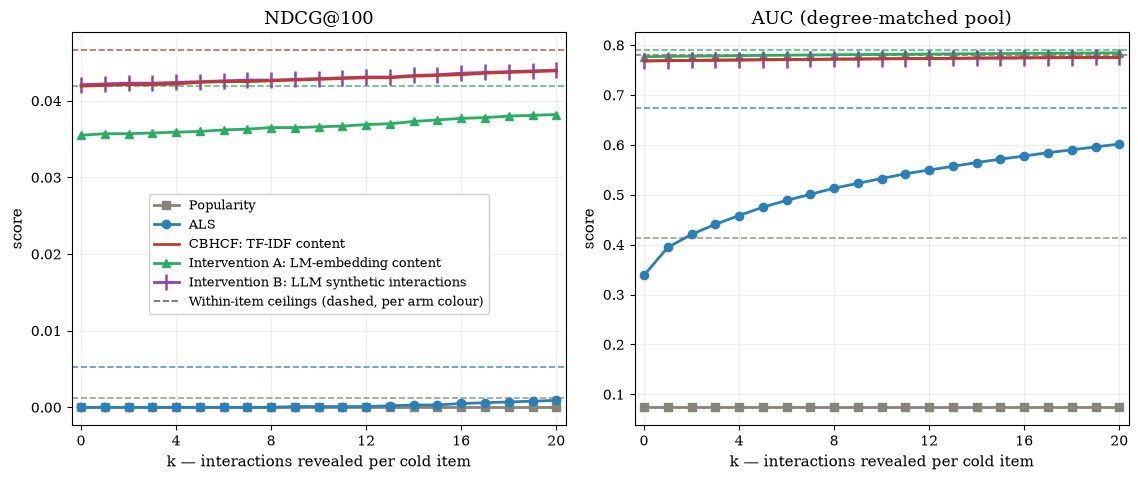

In [2]:
ma = D['mode_a']
ARMS_A = ['Popularity', 'ALS', 'CBHCF', 'Intervention A', 'Intervention B']

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.9), sharex=True)
draw_panel(axes[0], ma['k_levels'], ma['curves'], 'NDCG', ARMS_A, ma['ceilings'], 'NDCG@100')
draw_panel(axes[1], ma['k_levels'], ma['curves'], 'AUC',  ARMS_A, ma['ceilings'], 'AUC (degree-matched pool)')
for ax in axes:
    ax.set_xlabel('k — interactions revealed per cold item')
legend_at(axes[0], ARMS_A, xy=(10, 0.02))
fig.tight_layout()
save(fig, 'poster_mode_a')
plt.show()


## Poster — Mode A, two panels **stacked** and poster-scaled

The landscape version above is designed at 11.5 in wide; placed in the poster's ~5 in middle column it
shrinks to ~40 %, so 10 pt text lands at 4 pt. This version is built for that column: portrait 2×1 so
each panel gets the full column width, and fonts / lines / markers sized so they read at ~5 in wide.
Legend labels are shortened and the legend sits in the AUC panel's empty band. The poster's bullet list is
replaced by **callouts on the figure**; the two percentages are computed from the JSON, not typed in.
Writes `poster_mode_a_stacked`.

wrote ../outputs/poster_mode_a_stacked.png and .pdf


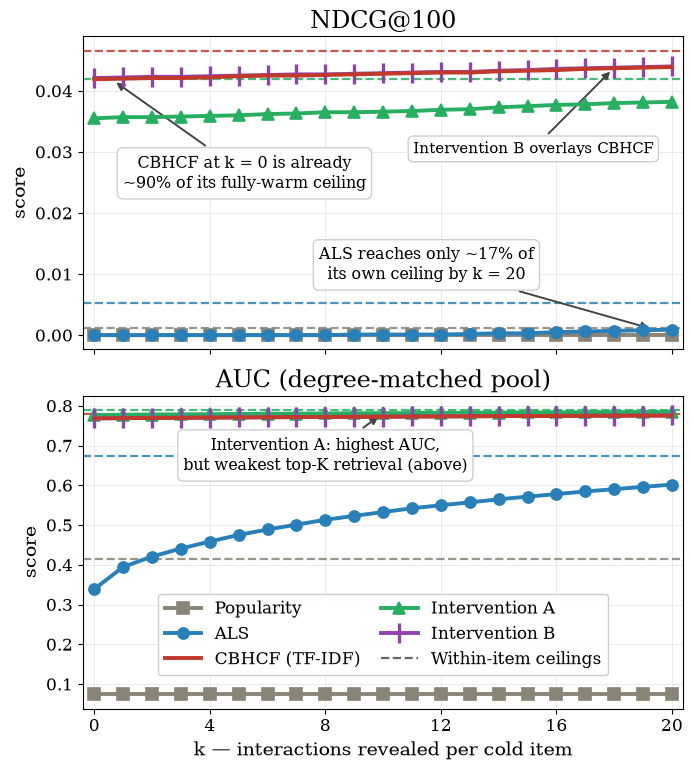

In [26]:
ma = D['mode_a']
ARMS_A = ['Popularity', 'ALS', 'CBHCF', 'Intervention A', 'Intervention B']
SHORT = {'Popularity': 'Popularity', 'ALS': 'ALS', 'CBHCF': 'CBHCF (TF-IDF)',
         'Intervention A': 'Intervention A', 'Intervention B': 'Intervention B'}
c = ma['curves']; ceil = ma['ceilings']
pct_cbhcf_k0 = 100 * c['CBHCF']['NDCG'][0]  / ceil['CBHCF']['NDCG']     # 0.0419 / 0.0466 -> ~90 %
pct_als_k20  = 100 * c['ALS']['NDCG'][20]   / ceil['ALS']['NDCG']       # 0.0009 / 0.0053 -> ~17 %

# poster scale: figure is 6 in wide, shown at ~5 in -> ~85 %, so sizes below are roughly what prints
with plt.rc_context({'axes.titlesize': 17, 'axes.labelsize': 14, 'xtick.labelsize': 12,
                     'ytick.labelsize': 12, 'legend.fontsize': 12}):
    fig, axes = plt.subplots(2, 1, figsize=(7.04, 7.8), sharex=True)
    for ax, (metric, title) in zip(axes, [('NDCG', 'NDCG@100'), ('AUC', 'AUC (degree-matched pool)')]):
        for arm in ARMS_A:
            if arm != 'Intervention B':
                ax.axhline(ceil[arm][metric], color=ARMS[arm][0], linestyle='--',
                           linewidth=1.6, alpha=0.85, zorder=1)
        order = ['Popularity', 'ALS', 'Intervention A', 'Intervention B', 'CBHCF']
        for i, arm in enumerate(order):
            color, marker, _ = ARMS[arm]
            mk = {} if marker is None else dict(marker=marker, markersize=15 if marker == '|' else 8,
                                                 markeredgewidth=2.4 if marker == '|' else 1.2)
            ax.plot(ma['k_levels'], c[arm][metric], color=color, linewidth=2.8,
                    zorder=3 + i * 0.1, **mk)
        ax.set_title(title); ax.set_ylabel('score')
        ax.set_xlim(-0.4, 20.4); ax.set_xticks(range(0, 21, 4))
        ax.grid(True, alpha=0.25, linewidth=0.7); ax.set_axisbelow(True)
    axes[-1].set_xlabel('k — interactions revealed per cold item')

    # --- callouts replace the poster's bullet list; both numbers are computed above from the JSON ---
    ANN = dict(fontsize=11.5, ha='center', va='center',
               bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='#cccccc', alpha=0.95),
               arrowprops=dict(arrowstyle='-|>', color='#444444', lw=1.4, shrinkB=4))
    ax0 = axes[0]
    ax0.annotate(f'CBHCF at k = 0 is already\n~{pct_cbhcf_k0:.0f}% of its fully-warm ceiling',
                 xy=(0.6, c['CBHCF']['NDCG'][0]), xytext=(5.2, 0.0265), **ANN)
    ax0.annotate(f'ALS reaches only ~{pct_als_k20:.0f}% of\nits own ceiling by k = 20',
                 xy=(19.4, c['ALS']['NDCG'][20]), xytext=(11.5, 0.0115), **ANN)
    ax0.annotate('Intervention B overlays CBHCF',
                 xy=(18, c['Intervention B']['NDCG'][18]), xytext=(15.2, 0.0305),
                 **{**ANN, 'fontsize': 10.5})
    ax1 = axes[1]
    ax1.annotate('Intervention A: highest AUC,\nbut weakest top-K retrieval (above)',
                 xy=(10, c['Intervention A']['AUC'][10]), xytext=(8, 0.675), **ANN)


    # legend lives in the AUC panel's empty band (between Popularity and the ALS curve)
    handles = [Line2D([], [], color=ARMS[a][0], linewidth=2.8, label=SHORT[a],
                      **({} if ARMS[a][1] is None else dict(marker=ARMS[a][1],
                         markersize=15 if ARMS[a][1] == '|' else 8,
                         markeredgewidth=2.4 if ARMS[a][1] == '|' else 1.2))) for a in ARMS_A]
    handles.append(Line2D([], [], color='#666666', linestyle='--', linewidth=1.6, label='Within-item ceilings'))
    ax1.legend(handles=handles, loc='center', bbox_to_anchor=(10, 0.225), bbox_transform=ax1.transData,
               ncol=2, frameon=True, framealpha=0.95, edgecolor='#cccccc', columnspacing=1.2, handlelength=2.2)
    fig.tight_layout()
    save(fig, 'poster_mode_a_stacked')
    plt.show()


## Report Figure 2 — Mode A, four panels stacked (NDCG, Recall, Hit Rate, AUC), portrait

wrote ../outputs/report_fig2_mode_a.png and .pdf


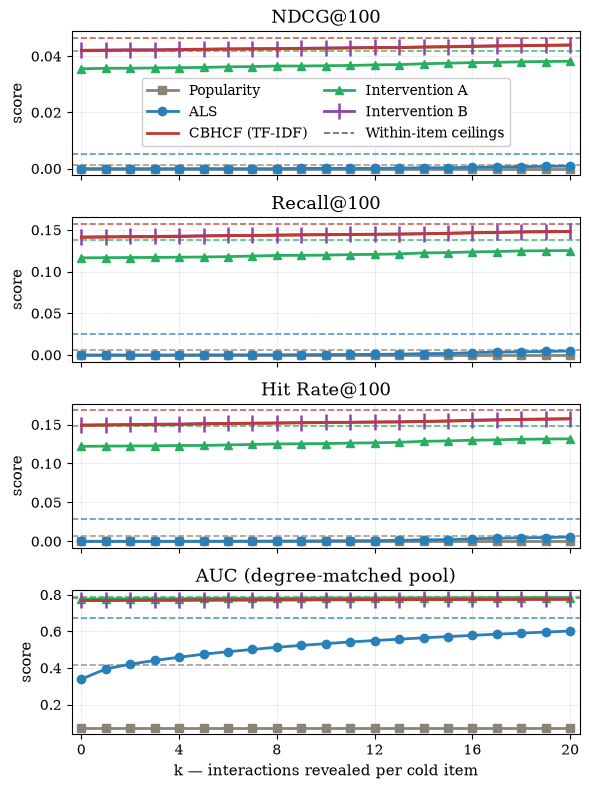

In [ ]:
PANELS_A = [('NDCG', 'NDCG@100'), ('Recall', 'Recall@100'),
            ('HitRate', 'Hit Rate@100'), ('AUC', 'AUC (degree-matched pool)')]
SHORT = {'Popularity': 'Popularity', 'ALS': 'ALS', 'CBHCF': 'CBHCF (TF-IDF)',
         'Intervention A': 'Intervention A', 'Intervention B': 'Intervention B'}

fig, axes = plt.subplots(4, 1, figsize=(6.0, 8.0), sharex=True)
for ax, (metric, title) in zip(axes, PANELS_A):
    draw_panel(ax, ma['k_levels'], ma['curves'], metric, ARMS_A, ma['ceilings'], title)
axes[-1].set_xlabel('k — interactions revealed per cold item')

# brief two-column legend (poster style), in the NDCG panel's empty band
handles = [Line2D([], [], color=ARMS[a][0], linestyle='-', linewidth=2.0,
                  label=SHORT[a], **style(ARMS[a][1])) for a in ARMS_A]
handles.append(Line2D([], [], color='#666666', linestyle='--', linewidth=1.2,
                      label='Within-item ceilings'))
axes[0].legend(handles=handles, loc='center', bbox_to_anchor=(10, 0.02),
               bbox_transform=axes[0].transData, ncol=2, fontsize=10,
               frameon=True, framealpha=0.95, edgecolor='#cccccc',
               columnspacing=1.2, handlelength=2.2)

# fig.suptitle('Mode A Warm-up Curves (K = 100)', fontweight='bold', y=0.995) # optional - un-comment-out if you want the title to appear
fig.tight_layout()
save(fig, 'report_fig2_mode_a')
plt.show()

## Report Figure 3 — Mode B, AUC (full user population) + Hit Rate@10, portrait

The Activity floor is Popularity's Mode B dual (rank users by total interaction count) — same grey squares.
Its AUC is flat at 0.6724 because user activity is frozen; that, not 0.5, is the effective null here
(Mode B AUC is not degree-matched). Activity has no within-item ceiling.

wrote ../outputs/report_fig3_mode_b.png and .pdf


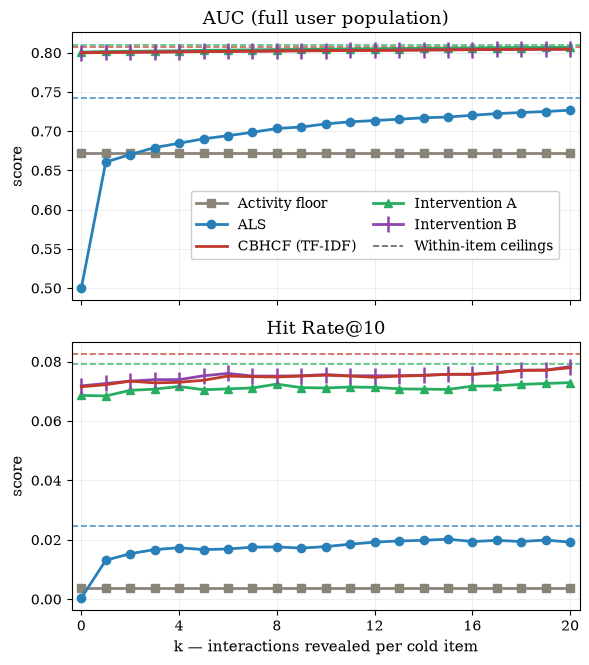

In [ ]:
mb = D['mode_b']
ARMS_B = ['Activity', 'ALS', 'CBHCF', 'Intervention A', 'Intervention B']
SHORT_B = {'Activity': 'Activity floor', 'ALS': 'ALS', 'CBHCF': 'CBHCF (TF-IDF)',
           'Intervention A': 'Intervention A', 'Intervention B': 'Intervention B'}

fig, axes = plt.subplots(2, 1, figsize=(6.0, 6.75), sharex=True)
draw_panel(axes[0], mb['k_levels'], mb['curves'], 'AUC',     ARMS_B, mb['ceilings'], 'AUC (full user population)')
draw_panel(axes[1], mb['k_levels'], mb['curves'], 'HitRate', ARMS_B, mb['ceilings'], 'Hit Rate@10')
axes[-1].set_xlabel('k — interactions revealed per cold item')

# brief two-column legend (poster style), in the empty region under the ALS curve
handles = [Line2D([], [], color=ARMS[a][0], linestyle='-', linewidth=2.0,
                  label=SHORT_B[a], **style(ARMS[a][1])) for a in ARMS_B]
handles.append(Line2D([], [], color='#666666', linestyle='--', linewidth=1.2,
                      label='Within-item ceilings'))
axes[0].legend(handles=handles, loc='center', bbox_to_anchor=(12.0, 0.58),
               bbox_transform=axes[0].transData, ncol=2, fontsize=10,
               frameon=True, framealpha=0.95, edgecolor='#cccccc',
               columnspacing=1.2, handlelength=2.2)

# fig.suptitle('Mode B Warm-up Curves (K = 10)', fontweight='bold', y=0.995) # optional - un-comment-out if you want the title to appear
fig.tight_layout()
save(fig, 'report_fig3_mode_b')
plt.show()


## Report Figure 4 — Provider-side exposure equity, Gini + cold-item exposure share, portrait

Per-k equity values were **never printed** in the steel thread, so `figure_curves.json` holds only k=0 and
k=20. If `../outputs/baseline_cf_20260815_012902.json` is present this cell draws the full curves from it;
otherwise it draws the two printed endpoints joined by a dotted line and says so in the panel title.
No ceilings are drawn: the Gini ceilings sit within 0.0004 of the curves and would just overprint them.

equity: full per-k curves from baseline_cf_20260815_012902.json
wrote ../outputs/report_fig4_equity.png and .pdf


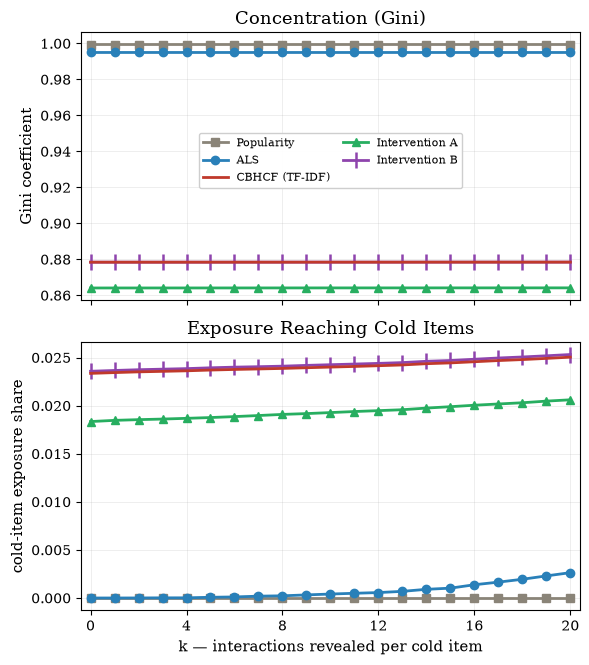

In [ ]:
eqd = D['equity']
ARMS_E = ['Popularity', 'ALS', 'CBHCF', 'Intervention A', 'Intervention B']
SHORT_E = {'Popularity': 'Popularity', 'ALS': 'ALS', 'CBHCF': 'CBHCF (TF-IDF)',
           'Intervention A': 'Intervention A', 'Intervention B': 'Intervention B'}
LABEL_IN_RESULTS = {'Intervention B': 'IB-reasoning'}       # results-JSON key for the IB reasoning arm

results_path = OUT / 'baseline_cf_20260815_012902.json'
per_k = False
if results_path.exists():
    try:
        R = json.loads(results_path.read_text())['mode_a']['equity']['curves']
        ks_e = list(range(21))
        eq_curves = {a: {'gini': R[LABEL_IN_RESULTS.get(a, a)]['log']['gini']['mean'],
                         'cold_exposure_share': R[LABEL_IN_RESULTS.get(a, a)]['log']['cold_exposure_share']['mean']}
                     for a in ARMS_E}
        per_k = True
        print('equity: full per-k curves from', results_path.name)
    except Exception as e:                                   # wrong shape -> fall back, but say why
        print('equity: could not read per-k curves from results JSON:', e)
if not per_k:
    ks_e = eqd['k_levels']
    eq_curves = {a: eqd['curves'][a] for a in ARMS_E}
    print('equity: ENDPOINTS ONLY (k=0, k=20) from the printed recap; per-k needs the results JSON')

fig, axes = plt.subplots(2, 1, figsize=(6.0, 6.75), sharex=True)
suffix = '' if per_k else '  (endpoints only)'
draw_panel(axes[0], ks_e, eq_curves, 'gini', ARMS_E, None,
           'Concentration (Gini)' + suffix, ylabel='Gini coefficient')
draw_panel(axes[1], ks_e, eq_curves, 'cold_exposure_share', ARMS_E, None,
           'Exposure Reaching Cold Items' + suffix, ylabel='cold-item exposure share')
if not per_k:                                                # make the interpolation visibly provisional
    for ax in axes:
        for line in ax.get_lines():
            line.set_linestyle(':'); line.set_linewidth(1.4)
axes[-1].set_xlabel('k — interactions revealed per cold item')
axes[-1].set_xlim(-0.4, 20.4)

# brief two-column legend (poster style), in the empty band between the two Gini clusters; no ceilings drawn
handles = [Line2D([], [], color=ARMS[a][0], linestyle='-', linewidth=2.0,
                  label=SHORT_E[a], **style(ARMS[a][1])) for a in ARMS_E]
axes[0].legend(handles=handles, loc='center', bbox_to_anchor=(10, 0.935),
               bbox_transform=axes[0].transData, ncol=2, fontsize=8,
               frameon=True, framealpha=0.95, edgecolor='#cccccc',
               columnspacing=1.2, handlelength=2.2)

# fig.suptitle('Provider-Side Exposure Equity', fontweight='bold', y=0.995) # optional - un-comment-out if you want the title to appear
fig.tight_layout()
save(fig, 'report_fig4_equity')
plt.show()